In [21]:
import os
import math
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import lightning
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import TQDMProgressBar

from mlcolvar.cvs import DeepLDA
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_files, load_dataframe
from mlcolvar.utils.trainer import MetricsCallback
from mlcolvar.utils.plot import plot_metrics
from mlcolvar.utils.fes import compute_fes
from mlcolvar.explain import sensitivity_analysis
import mlcolvar.utils.plot
import plumed


In [5]:
# Configurations
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data2"
GMX_CMD     = "gmx_mpi"  # I compiled gromacs with mpi support
#NUM_STEPS   = 10_000     # for testing  
NUM_STEPS   = 500_000    # productions 1ns
STRIDE      = 100

num_steps   = NUM_STEPS
sample_steps = 1_000_000
sample_stride = 100

os.chdir(BASE_DIR)
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [6]:
# helper functions

# delete outputs of simulations from `folder``
def clean(folder='./'):
    subprocess.run("rm -f bck.*.COLVAR bck.*.HILLS \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# delete outputs of simulations from `folder``
def clean_true(folder='./'):
    subprocess.run("rm -f bck.* COLVAR HILLS KERNELS alanine.* \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# execute bash command in the given folder
def execute(command, folder, background=False):
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output = True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

In [7]:
# CREATE FOLDER AND COPY INPUTS
folder_t1 = DATA_DIR / "90-test1/"
Path(folder_t1).mkdir(parents=True, exist_ok=True)

In [8]:
# copy model
folder_ml_rw = DATA_DIR / "2_meta-deeplda-rw/"
execute(f"cp {folder_ml_rw}/model.ptc .", folder_t1)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data2/2_meta-deeplda-rw/model.ptc .


In [9]:
model = torch.jit.load(f"{folder_t1}/model.ptc")
model.eval()

RecursiveScriptModule(
  original_name=DeepLDA
  (loss_fn): RecursiveScriptModule(original_name=ReduceEigenvaluesLoss)
  (norm_in): RecursiveScriptModule(original_name=Normalization)
  (nn): RecursiveScriptModule(
    original_name=FeedForward
    (nn): RecursiveScriptModule(
      original_name=Sequential
      (0): RecursiveScriptModule(original_name=Linear)
      (1): RecursiveScriptModule(original_name=Tanh)
      (2): RecursiveScriptModule(original_name=Linear)
      (3): RecursiveScriptModule(original_name=Tanh)
      (4): RecursiveScriptModule(original_name=Linear)
    )
  )
  (lda): RecursiveScriptModule(original_name=LDA)
)

In [10]:
filenames = [ f"{DATA_DIR}/0_unbiased-sA/COLVAR", 
              f"{DATA_DIR}/0_unbiased-sB/COLVAR" ]

n_states = len(filenames)

# load dataset
dataset, colvar = create_dataset_from_files(filenames,
                                        filter_args={'regex':'d_' }, # select distances between heavy atoms
                                        create_labels=True,
                                        return_dataframe=True, 
                                        )

# default parameters batch size = len(dataset), shuffle = True
datamodule = DictModule(dataset,lengths=[0.8,0.2])

Class 0 dataframe shape:  (10001, 53)
Class 1 dataframe shape:  (10001, 53)

 - Loaded dataframe (20002, 53): ['time', 'phi', 'psi', 'theta', 'xi', 'ene', 'd_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16', 'd_11_17', 'd_11_19', 'd_15_16', 'd_15_17', 'd_15_19', 'd_16_17', 'd_16_19', 'd_17_19', 'walker', 'labels']
 - Descriptors (20002, 45): ['d_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_

In [26]:
dataset['data']
with torch.no_grad():
    s = model(dataset['data'])

cv1_data = s[:, 0].detach().cpu().numpy()
internal_dict = getattr(dataset, '_dictionary', dataset)
labels = internal_dict['labels']
labels = labels.detach().cpu().numpy()
labels = labels.flatten()

States found in dataset: [np.float32(0.0), np.float32(1.0)]
State A: mean = -1.1335, sigma = 0.0161, frames = 10001
State B: mean = 1.1391, sigma = 0.0141, frames = 10001

Intra-basin Sigma (mean of states): 0.0151
Naive Sigma on entire dataset (overestimated, DO NOT USE): 1.1364



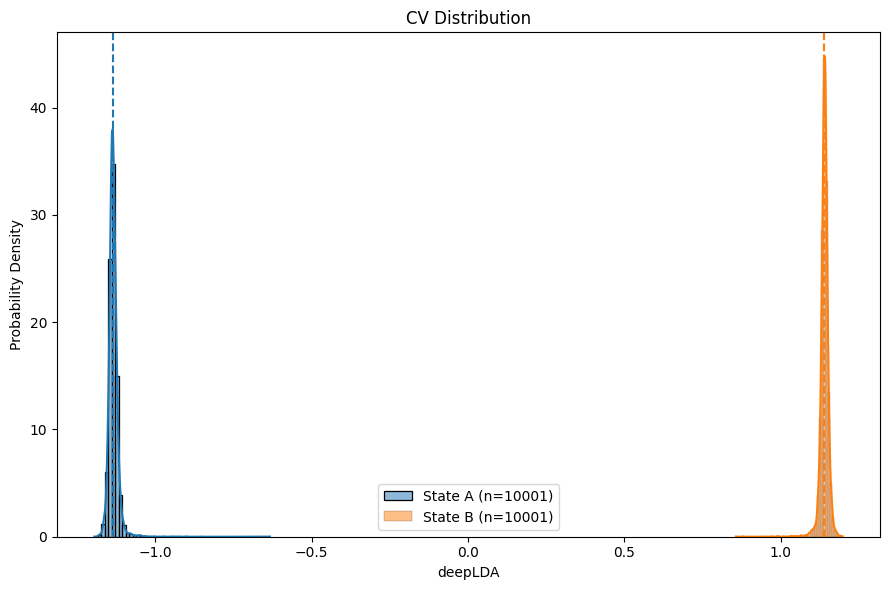

Physical Reference - Intra-basin Sigma: 0.0151
Comparison (Wrong) - Naive Sigma: 1.1364


In [ ]:
# 2. Setup state configurations
state_names = {0: 'State A', 1: 'State B'}
unique_states = sorted(np.unique(labels))
palette = {0: 'tab:blue', 1: 'tab:orange'}

print(f"States found in dataset: {unique_states}")

# 3. Process statistics and plotting
sigma_per_state = {}
plt.figure(figsize=(9, 6))

for st in unique_states:
    cv_state = cv1_data[labels == st]
    n_frames = len(cv_state)
    
    # Calculate stats
    mean_val, std_val = np.mean(cv_state), np.std(cv_state)
    sigma_per_state[st] = std_val
    
    name = state_names.get(int(st), f'State {int(st)}')
    color = palette.get(int(st))
    print(f"{name}: mean = {mean_val:.4f}, sigma = {std_val:.4f}, frames = {n_frames}")
    
    # Plot distribution
    sns.histplot(cv_state, kde=True, stat="density", color=color, alpha=0.5, bins=50,
                 label=f'{name} (n={n_frames})')
    
    # Add stats lines
    plt.axvline(mean_val, color=color, linestyle="--", linewidth=1.5)
    #plt.axvline(mean_val - std_val, color=color, linestyle=":", linewidth=1.2)
    #plt.axvline(mean_val + std_val, color=color, linestyle=":", linewidth=1.2)

# 4. Global physical metrics & Finalize Plot
sigma_intra = float(np.mean(list(sigma_per_state.values())))
sigma_naive = np.std(cv1_data)

print(f"\nIntra-basin Sigma (mean of states): {sigma_intra:.4f}")
print(f"Naive Sigma on entire dataset (overestimated, DO NOT USE): {sigma_naive:.4f}\n")

plt.xlabel('deepLDA')
plt.ylabel('Probability Density')
plt.title(r'CV Distribution')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Physical Reference - Intra-basin Sigma: {sigma_intra:.4f}")
print(f"Comparison (Wrong) - Naive Sigma: {sigma_naive:.4f}")